In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Define a function "brownian" for simulating a Brownian path
def brownian(interval, step):
  n = int(interval / step)
  B = [0]
  for i in range(n):
    B.append(np.sqrt(step) * np.random.standard_normal() + B[-1])
  return B

In [12]:
# Define a function "SDE" for simulating 5 paths of the solution of dX_t = mu(X_t)dt + sigma(X_t)dB_t, X_0=x0 on [0,1]
def SDE(mu, sigma, x0):
  x = np.linspace(0.0, 1.0, 101)
  for i in range(5):
    B = brownian(1, 0.01)
    S = [x0]
    for j in range(100):
      St = sigma(S[j]) * (B[j+1] - B[j]) + mu(S[j]) * 0.01 + S[j]
      S.append(St)
    plt.plot(x, S)

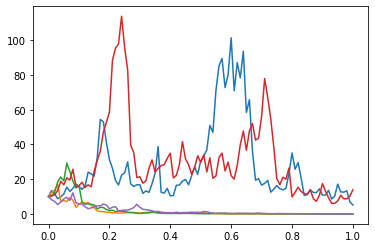

In [16]:
# Simulate 5 paths of the solution of dX_t = (2X_t)dt + 3X_t dB_t, X_0=10 (geometric BM) on [0,1]
mu = lambda x : 2 * x
sigma = lambda x : 3* x
SDE(mu, sigma, 10)

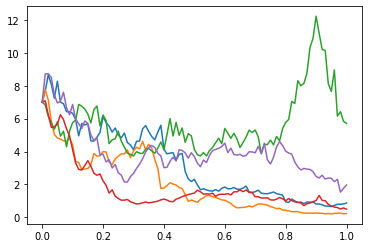

In [20]:
# Simulate 5 paths of the solution of dX_t = -X_tdt + dB_t, X_0=1 (Ornstein-Uhlenbeck process) on [0,1]
mu = lambda x : (-1) * x
sigma = lambda x : x
SDE(mu, sigma, 7)

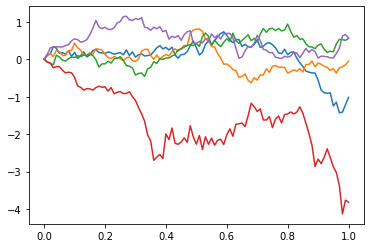

In [21]:
# Simulate 5 paths of the solution of dX_t = sin(X_t)dt + sqrt(1+X_t^2) dB_t, X_0=0 on [0,1]
mu = lambda x : np.sin(x)
sigma = lambda x : np.sqrt(1 + x**2)
SDE(mu, sigma, 0)